# Structural Analysis of the OGBN-Arxiv Dataset

This notebook performs a structural analysis of the OGBN-Arxiv dataset

In [4]:
import sys
import os
import time
import random
import json

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.utils import to_networkx
from torch_geometric.transforms import NormalizeFeatures

import networkx as nx

In [5]:
sns.set_style("white")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": False
})

os.makedirs("../../results/plots/arxiv", exist_ok=True)
os.makedirs("../../results/tables/arxiv", exist_ok=True)

## Dataset

The experiments are conducted on the OGBN-Arxiv dataset

In [6]:
dataset = PygNodePropPredDataset(
    name="ogbn-arxiv",
    root="../../data",
    transform=NormalizeFeatures()
)

data = dataset[0]

print(dataset)
print(data)

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:45<00:00,  1.79it/s]
Processing...


Extracting ../../data\arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<?, ?it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<?, ?it/s]

Saving...



c:\Master\GAI\gnn-over-squashing-cora\.venv\Lib\site-packages\ogb\nodeproppred\dataset_pyg.py:187: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  data.y = torch.from_numpy(node_label).to(torch.long)
Done!


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torch_geometric.data.data.DataEdgeAttr was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])` or the `torch.serialization.safe_globals([torch_geometric.data.data.DataEdgeAttr])` context manager to allowlist this global if you trust this class/function.

Check the documentat

## Models

In [4]:
sys.path.append(os.path.abspath("../.."))

from src.models.node_classification import GCN, GraphSAGE, GAT

from src.training.train import train_node_classification
from src.training.evaluate import evaluate_node_classification

from src.utils.seed import set_seed

## Effect of Model Depth

The experiment evaluates GCN models with varying numbers of layers. The objective is to observe whether increasing the number of message-passing steps leads to improved performance or, alternatively, to performance degradation.

A consistent drop in accuracy for deeper models may indicate the presence of information bottlenecks that limit the effective propagation of signals through the graph.

In [5]:
def plot(history):
    epochs = range(len(history["train_loss"]))

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    axs[0].plot(epochs, history["train_loss"], label="train")
    if "val_loss" in history:
        axs[0].plot(epochs, history["val_loss"], linestyle="--", label="val")

    axs[0].set_title("Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()

    # --- Accuracy ---
    axs[1].plot(epochs, history["train_acc"], label="train")
    if "val_acc" in history:
        axs[1].plot(epochs, history["val_acc"], linestyle="--", label="val")

    axs[1].set_title("Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

models = {
    "gcn": GCN,
    "graphsage": GraphSAGE,
    "gat": GAT
}

in_dim = dataset.num_features
num_classes = dataset.num_classes

hidden_dim = 16
epochs = 400
lr = 0.005
weight_decay = 1e-3
dropout = 0.7

layer_values = [2, 4, 6, 8]
seeds = [0, 1, 2, 3, 4]

results = {m: {"layers": [], "acc_mean": [], "acc_std": [], "time": []} for m in models.keys()}

data = data.to(device)

for model_name, ModelClass in models.items():

    print(f"\nRunning experiments for {model_name.upper()}")

    for num_layers in layer_values:
        acc_runs = []
        time_runs = []

        for seed in seeds:

            set_seed(seed)

            model = ModelClass(in_dim, hidden_dim, num_classes, num_layers, dropout).to(device)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay,
            )

            start = time.time()

            history = train_node_classification(
                model,
                data,
                optimizer,
                epochs=epochs
            )

            end = time.time()
            elapsed = end - start

            acc = evaluate_node_classification(
                model,
                data,
            )
            acc_runs.append(acc)
            time_runs.append(elapsed)

            plot(history)

        # estadísticas
        acc_mean = np.mean(acc_runs)
        acc_std = np.std(acc_runs)

        results[model_name]["layers"].append(num_layers)
        results[model_name]["acc_mean"].append(acc_mean)
        results[model_name]["acc_std"].append(acc_std)
        results[model_name]["time"].append(np.mean(time_runs))

        print(
            f"Layers: {num_layers} | "
            f"Accuracy: {acc_mean:.4f} ± {acc_std:.4f}"
        )

In [69]:
colors = {
    "gcn": "#4C72B0",
    "graphsage": "#55A868",
    "gat": "#C44E52"
}

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

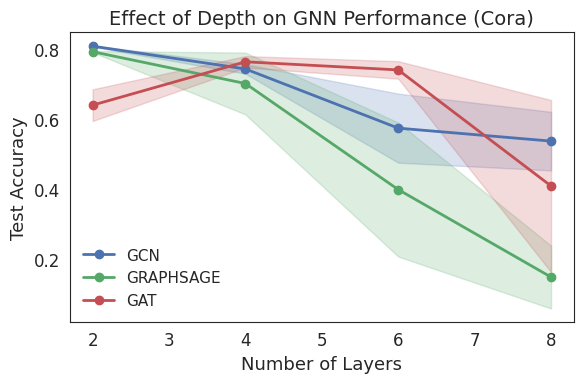

In [ ]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    layers = data["layers"]
    mean = np.array(data["acc_mean"])
    std = np.array(data["acc_std"])

    plt.plot(
        layers,
        mean,
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

    # banda de variabilidad (mean ± std)
    plt.fill_between(
        layers,
        mean - std,
        mean + std,
        color=colors[model],
        alpha=0.2
    )

plt.xlabel("Number of Layers")
plt.ylabel("Test Accuracy")

plt.title("Effect of Depth on GNN Performance (OGBN-Arxiv)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../../results/plots/arxiv/accuracy_vs_layers.png", dpi=300)

plt.show()

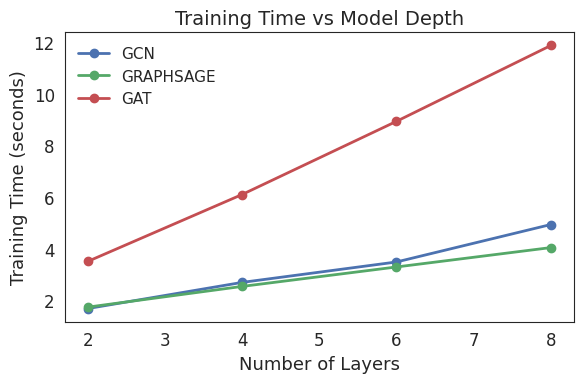

In [ ]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    plt.plot(
        data["layers"],
        data["time"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

plt.xlabel("Number of Layers")
plt.ylabel("Training Time (seconds)")

plt.title("Training Time vs Model Depth (OGBN-Arxiv)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../../results/plots/arxiv/time_vs_layers.png", dpi=300)

plt.show()

In [ ]:
rows = []
for model in results:
    for i in range(len(results[model]["layers"])):
        rows.append({
            "model": model,
            "layers": results[model]["layers"][i],
            "accuracy_mean": results[model]["acc_mean"][i],
            "accuracy_std": results[model]["acc_std"][i],
            "time": results[model]["time"][i]
        })

df = pd.DataFrame(rows)
df.to_csv("../../results/tables/arxiv/gnn_layer_experiments.csv", index=False)

In [ ]:
with open("../../results/tables/arxiv/gnn_layer_experiments.json", "w") as f:
    json.dump(results, f, indent=4)

## Graph Structural Properties

Oversquashing is closely related to structural bottlenecks in the graph. Intuitively, if many nodes must communicate through a small number of edges, information from distant parts of the graph becomes compressed as it propagates.

One way to explore this is to analyze how the size of a node's neighborhood grows as the number of hops increases.

In [8]:
G = to_networkx(data, to_undirected=True)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print("Average degree:", avg_degree)

Number of nodes: 2277
Number of edges: 31421
Average degree: 27.598594642072904


## Neighborhood Growth

If information could propagate freely through the graph, the number of reachable nodes should grow rapidly as the number of hops increases.

However, in graphs with structural bottlenecks, this expansion may be much slower. This means that information from large parts of the graph must be compressed through a limited number of edges, which is precisely the mechanism behind oversquashing.

The following analysis measures how the size of node neighborhoods grows as the hop distance increases.

In [9]:
from collections import deque

def k_hop_neighbors(G, start, k):
    
    visited = {start}
    queue = deque([(start, 0)])
    
    while queue:
        node, depth = queue.popleft()
        
        if depth == k:
            continue
            
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))
                
    return len(visited)

sample_nodes = random.sample(list(G.nodes()), 200)

max_k = 12
growth = []

for k in range(1, max_k + 1):
    
    sizes = []
    
    for node in sample_nodes:
        sizes.append(k_hop_neighbors(G, node, k))
        
    growth.append(sum(sizes) / len(sizes))

## Expansion of k-hop neighborhoods

The following plot shows how the average number of reachable nodes grows with increasing hop distance.

If the expansion saturates quickly, it suggests that the graph contains structural bottlenecks that may restrict information flow.

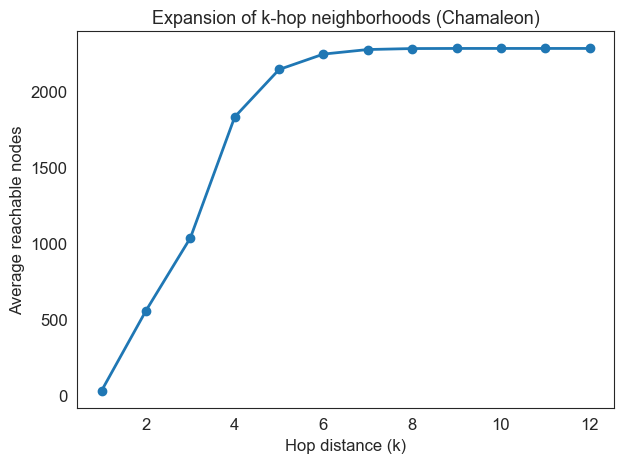

In [ ]:
plt.figure()

plt.plot(
    range(1, max_k + 1),
    growth,
    marker="o",
    linewidth=2,
)

plt.xlabel("Hop distance (k)")
plt.ylabel("Average reachable nodes")

plt.title("Expansion of k-hop neighborhoods (OGBN-Arxiv)")

plt.tight_layout()

plt.savefig(
    "../../results/plots/arxiv/khop_neighborhood_growth.png",
    dpi=300
)

plt.show()

## Local Bottlenecks via Edge Betweenness Centrality

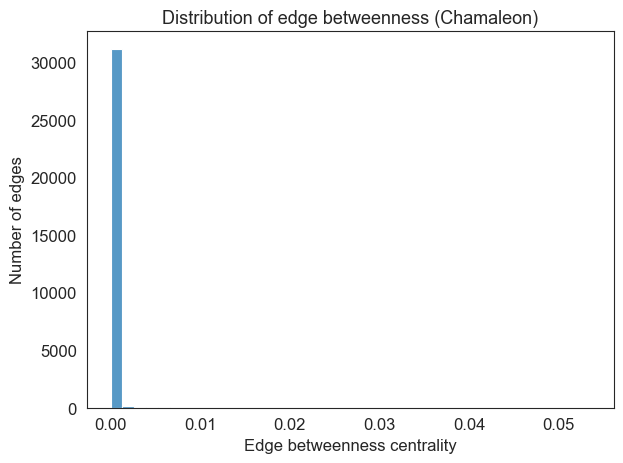

In [ ]:
values = np.array(list(nx.edge_betweenness_centrality(G).values()))

plt.figure()

sns.histplot(
    values,
    bins=40,
    kde=False
)

plt.xlabel("Edge betweenness centrality")
plt.ylabel("Number of edges")

plt.title("Distribution of edge betweenness (OGBN-Arxiv)")

plt.tight_layout()

plt.savefig(
    "../../results/plots/arxiv/edge_betweenness_distribution.png",
    dpi=300
)

plt.show()

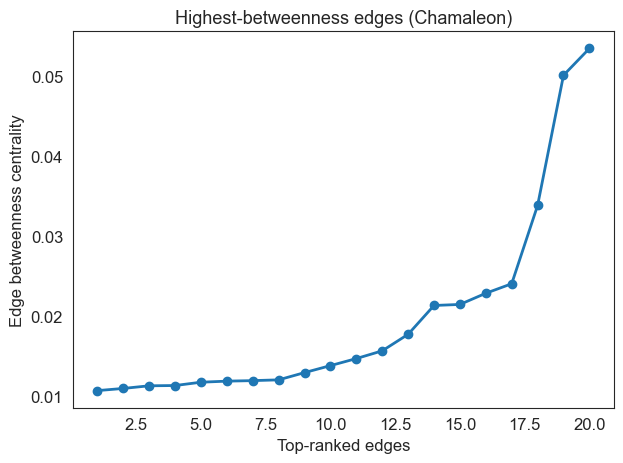

In [ ]:
top_values = np.sort(values)[-20:]

plt.figure()

plt.plot(
    range(1, len(top_values)+1),
    top_values,
    marker="o",
    linewidth=2
)

plt.xlabel("Top-ranked edges")
plt.ylabel("Edge betweenness centrality")

plt.title("Highest-betweenness edges (OGBN-Arxiv)")

plt.tight_layout()

plt.savefig(
    "../../results/plots/arxiv/highest_betweenness_edges.png",
    dpi=300
)

plt.show()